# Rule-Based Policy — LunarLander-v2

A corrected and complete rule-based baseline with:
- **Full state usage** — x, y, vx, vy, angle, angular_vel, left_leg, right_leg all used
- **Horizontal correction** — actively steers toward landing pad (x=0)
- **Landing detection** — cuts engines when both legs touch down
- **Priority-ordered rules** — safety first, then alignment, then descent
- **Correct termination reason** — distinguishes crash vs timeout vs landing
- **max_steps=1000** to match LunarLander's natural episode length
- **Seeded for reproducibility**

**Graph improvements (this version):**
- Per-episode reward bars coloured by outcome with rolling mean overlay
- Best / worst / mean horizontal annotation lines on reward plot
- Reward distribution histogram split by outcome with std dev band
- Outcome breakdown with counts, percentages and mean reward per outcome
- Action usage bar chart showing which rules fired most
- Consistent styling with PPO / DQN / A2C notebooks

In [1]:
# Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import glob
from collections import deque, Counter
from IPython.display import Video, display

SEED = 42
np.random.seed(SEED)
print('Imports done.')

Imports done.


In [2]:
# Config
ENV_NAME     = 'LunarLander-v2'
NUM_ENVS     = 4
NUM_EPISODES = 200
MAX_STEPS    = 1000
SOLVE_REWARD = 200
SOLVE_WINDOW = 100

# Consistent colour palette with all RL notebooks
C_LANDED  = '#1D9E75'
C_CRASHED = '#D85A30'
C_TIMEOUT = '#BA7517'
C_ROLLING = '#185FA5'
C_STEPS   = '#534AB7'
C_MEAN    = '#7F77DD'

print('Config set.')

Config set.


In [3]:
# Rule-based policy — full state utilisation
def rule_policy(obs):
    """
    Priority-ordered rules for LunarLander-v2.
    Returns (action, rule_id) so we can track which rule fired.

    Actions:
      0 = do nothing
      1 = fire left engine
      2 = fire main engine
      3 = fire right engine
    """
    x, y, vx, vy, angle, angular_vel, left_leg, right_leg = obs

    if left_leg and right_leg:                          return 0, 'R1:both_legs'
    if angle > 0.4:                                     return 3, 'R2:tilt_right'
    if angle < -0.4:                                    return 1, 'R2:tilt_left'
    if vy < -0.8 or (y > 1.0 and vy < 0):              return 2, 'R3:fall_fast'
    if x > 0.15 or vx > 0.3:                           return 3, 'R4:drift_right'
    if x < -0.15 or vx < -0.3:                         return 1, 'R4:drift_left'
    if angle > 0.1 or angular_vel > 0.2:               return 3, 'R5:fine_angle'
    if angle < -0.1 or angular_vel < -0.2:             return 1, 'R5:fine_angle'
    if vy < -0.4:                                       return 2, 'R6:mod_descent'
    return 0, 'R7:coast'


_test_obs = [0.0, 0.5, 0.0, -0.9, 0.0, 0.0, 0, 0]
assert rule_policy(_test_obs)[0] == 2
print('Rule policy defined and sanity-checked.')

Rule policy defined and sanity-checked.


In [4]:
# Run episodes — also collects per-step rule usage
def run_episodes(num_episodes=NUM_EPISODES, num_envs=NUM_ENVS, max_steps=MAX_STEPS):
    env = gym.vector.make(ENV_NAME, num_envs=num_envs)
    env.reset(seed=SEED)

    rewards_history = []
    steps_history   = []
    reasons_history = []
    rule_counter    = Counter()   # tracks which rules fire most
    rolling_rewards = deque(maxlen=SOLVE_WINDOW)

    completed   = 0
    env_rewards = np.zeros(num_envs)
    env_steps   = np.zeros(num_envs, dtype=int)

    obs, _ = env.reset()

    while completed < num_episodes:
        action_rule_pairs = [rule_policy(obs[i]) for i in range(num_envs)]
        actions = [p[0] for p in action_rule_pairs]
        rules   = [p[1] for p in action_rule_pairs]

        next_obs, rewards, terminated, truncated, _ = env.step(actions)
        dones = terminated | truncated

        for rule in rules:
            rule_counter[rule] += 1

        for i in range(num_envs):
            env_rewards[i] += rewards[i]
            env_steps[i]   += 1

        obs = next_obs

        for i in range(num_envs):
            if dones[i] and completed < num_episodes:
                completed += 1

                if truncated[i]:
                    reason = 'timeout'
                elif env_rewards[i] >= 100:
                    reason = 'landed'
                else:
                    reason = 'crashed'

                rolling_rewards.append(env_rewards[i])
                rewards_history.append(env_rewards[i])
                steps_history.append(int(env_steps[i]))
                reasons_history.append(reason)

                if completed % 20 == 0:
                    roll_mean = np.mean(rolling_rewards)
                    print(f'Ep {completed:4d} | steps {env_steps[i]:4d} | '
                          f'reward {env_rewards[i]:8.2f} | '
                          f'rolling{SOLVE_WINDOW} {roll_mean:7.2f} | {reason}')

                env_rewards[i] = 0
                env_steps[i]   = 0

    env.close()
    return rewards_history, steps_history, reasons_history, rule_counter

print('run_episodes defined.')

run_episodes defined.


In [5]:
# Run evaluation
print(f'=== Rule-Based Policy — LunarLander-v2 ({NUM_EPISODES} episodes) ===')
rewards, steps, reasons, rule_counter = run_episodes(NUM_EPISODES)

=== Rule-Based Policy — LunarLander-v2 (200 episodes) ===


c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\vector\__init__.py:53: UserWarning: WARN: `gymnasium.vector.make(...)` is deprecated and will be replaced by `gymnasium.make_vec(...)` in v1.0
  gym.logger.warn(


Ep   20 | steps  129 | reward   -65.87 | rolling100 -172.86 | crashed
Ep   40 | steps  446 | reward  -165.14 | rolling100 -184.69 | crashed
Ep   60 | steps  776 | reward  -340.24 | rolling100 -197.35 | crashed
Ep   80 | steps  192 | reward  -159.36 | rolling100 -195.19 | crashed
Ep  100 | steps  364 | reward  -266.26 | rolling100 -197.30 | crashed
Ep  120 | steps  252 | reward  -119.16 | rolling100 -201.63 | crashed
Ep  140 | steps  125 | reward  -187.91 | rolling100 -202.85 | crashed
Ep  160 | steps  165 | reward  -250.04 | rolling100 -194.49 | crashed
Ep  180 | steps  113 | reward   -34.69 | rolling100 -197.87 | crashed
Ep  200 | steps  234 | reward  -259.30 | rolling100 -199.05 | crashed


In [6]:
# Summary statistics
r = np.array(rewards)
reason_counts = {k: reasons.count(k) for k in ['landed', 'crashed', 'timeout']}

# Per-outcome mean rewards
landed_rewards  = [r[i] for i, o in enumerate(reasons) if o == 'landed']
crashed_rewards = [r[i] for i, o in enumerate(reasons) if o == 'crashed']
timeout_rewards = [r[i] for i, o in enumerate(reasons) if o == 'timeout']

print('=== Summary ===')
print(f'Episodes run          : {len(r)}')
print(f'Mean reward           : {r.mean():.2f} +/- {r.std():.2f}')
print(f'Best episode          : {r.max():.2f}')
print(f'Worst episode         : {r.min():.2f}')
print(f'Landed                : {reason_counts["landed"]:3d} ({100*reason_counts["landed"]/len(r):.1f}%) | mean {np.mean(landed_rewards):.1f}' if landed_rewards else f'Landed  : 0')
print(f'Crashed               : {reason_counts["crashed"]:3d} ({100*reason_counts["crashed"]/len(r):.1f}%) | mean {np.mean(crashed_rewards):.1f}' if crashed_rewards else f'Crashed : 0')
print(f'Timeout               : {reason_counts["timeout"]:3d} ({100*reason_counts["timeout"]/len(r):.1f}%) | mean {np.mean(timeout_rewards):.1f}' if timeout_rewards else f'Timeout : 0')
if len(r) >= SOLVE_WINDOW:
    final_mean = r[-SOLVE_WINDOW:].mean()
    status = 'above solve threshold' if final_mean >= SOLVE_REWARD else 'below solve threshold'
    print(f'Final {SOLVE_WINDOW}-ep mean    : {final_mean:.2f} ({status})')

=== Summary ===
Episodes run          : 200
Mean reward           : -198.18 +/- 73.07
Best episode          : -32.66
Worst episode         : -418.18
Landed  : 0
Crashed               : 200 (100.0%) | mean -198.2
Timeout : 0
Final 100-ep mean    : -199.05 (below solve threshold)


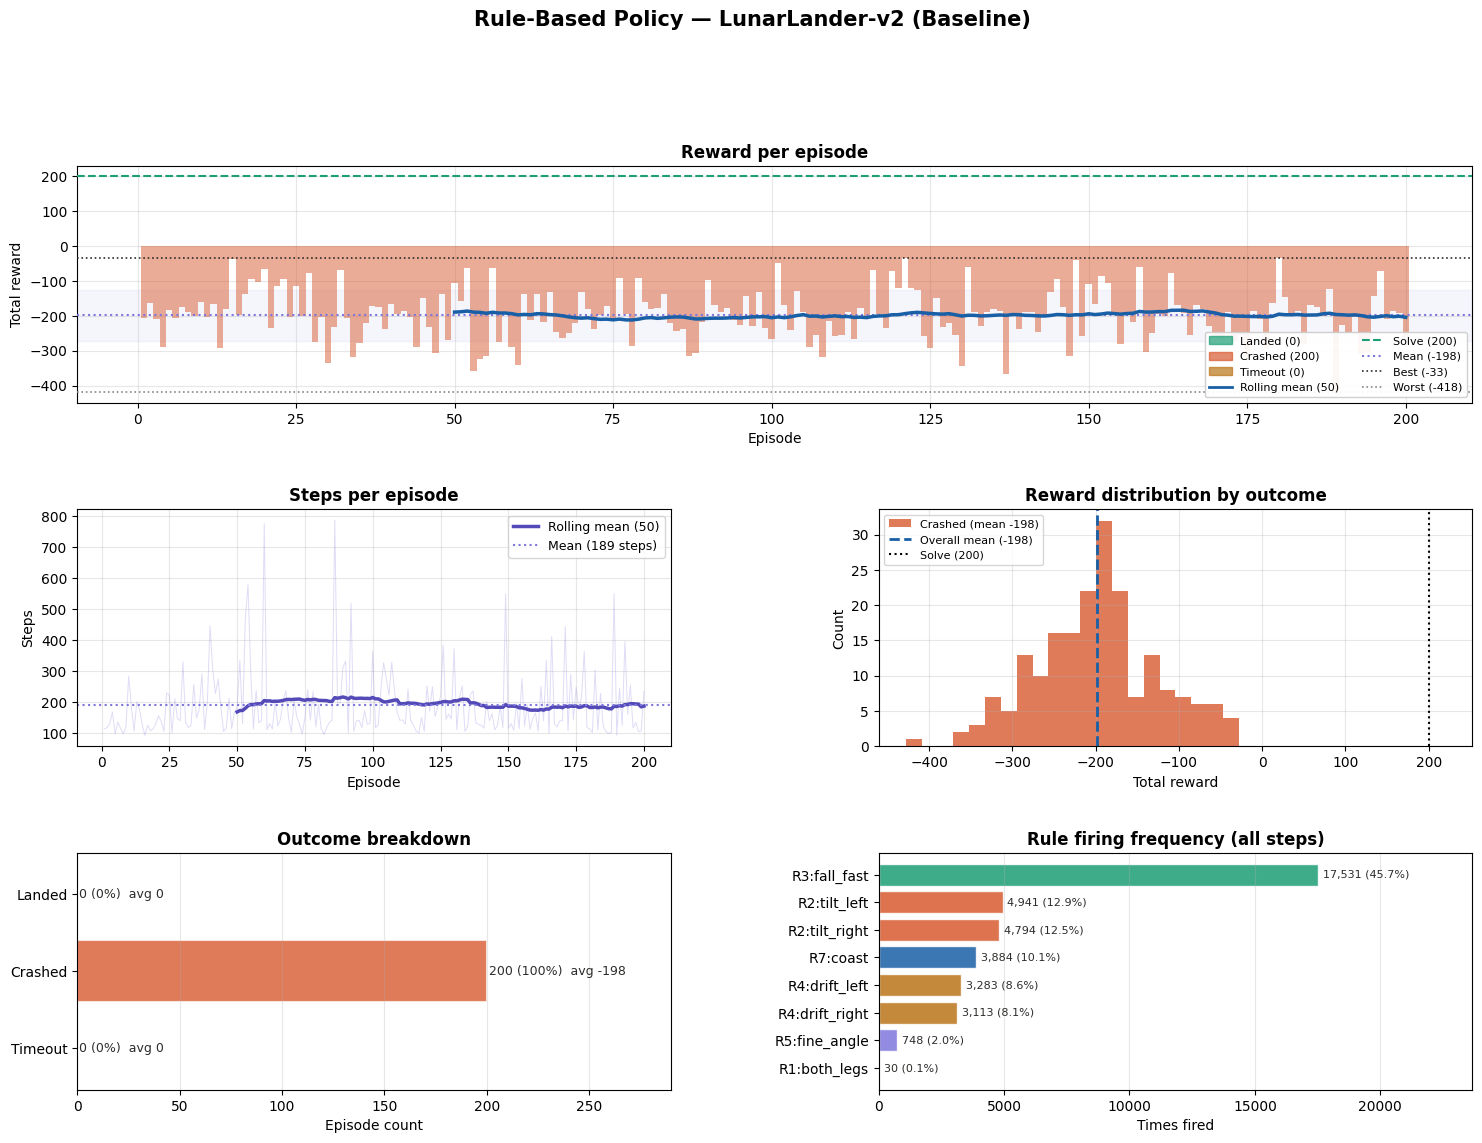

Plot saved to rulebased_results.png


In [7]:
# ── Improved plots ────────────────────────────────────────────────────────────
r_arr = np.array(rewards)
s_arr = np.array(steps)
eps   = np.arange(1, len(r_arr) + 1)
W     = 50

def rolling_mean(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid')

bar_colours = [C_LANDED if r == 'landed' else C_CRASHED if r == 'crashed' else C_TIMEOUT
               for r in reasons]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Rule-Based Policy — LunarLander-v2 (Baseline)',
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Reward per episode — coloured bars + rolling mean + annotations
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(eps, r_arr, color=bar_colours, alpha=0.5, width=1.0, zorder=2)
if len(r_arr) >= W:
    rm = rolling_mean(r_arr, W)
    ax1.plot(np.arange(W, len(r_arr) + 1), rm,
             color=C_ROLLING, linewidth=2.5, label=f'Rolling mean ({W})', zorder=4)

# Solve threshold
ax1.axhline(SOLVE_REWARD, color=C_LANDED, linestyle='--', linewidth=1.5,
            label=f'Solve threshold ({SOLVE_REWARD})', zorder=3)

# Best / worst / mean annotation lines
ax1.axhline(r_arr.mean(), color=C_MEAN, linestyle=':', linewidth=1.5,
            label=f'Mean ({r_arr.mean():.0f})', zorder=3)
ax1.axhline(r_arr.max(),  color='#2C2C2A', linestyle=':', linewidth=1.2,
            label=f'Best ({r_arr.max():.0f})', zorder=3)
ax1.axhline(r_arr.min(),  color='#888780', linestyle=':', linewidth=1.2,
            label=f'Worst ({r_arr.min():.0f})', zorder=3)

# Std dev band around mean
ax1.axhspan(r_arr.mean() - r_arr.std(), r_arr.mean() + r_arr.std(),
            alpha=0.07, color=C_MEAN, label=f'+/- 1 std ({r_arr.std():.0f})')

outcome_legend = [
    Patch(color=C_LANDED,  alpha=0.7, label=f'Landed ({reason_counts["landed"]})')  ,
    Patch(color=C_CRASHED, alpha=0.7, label=f'Crashed ({reason_counts["crashed"]})')  ,
    Patch(color=C_TIMEOUT, alpha=0.7, label=f'Timeout ({reason_counts["timeout"]})')  ,
    plt.Line2D([0],[0], color=C_ROLLING, linewidth=2,   label=f'Rolling mean ({W})'),
    plt.Line2D([0],[0], color=C_LANDED,  linewidth=1.5, linestyle='--', label=f'Solve ({SOLVE_REWARD})'),
    plt.Line2D([0],[0], color=C_MEAN,    linewidth=1.5, linestyle=':', label=f'Mean ({r_arr.mean():.0f})'),
    plt.Line2D([0],[0], color='#2C2C2A', linewidth=1.2, linestyle=':', label=f'Best ({r_arr.max():.0f})'),
    plt.Line2D([0],[0], color='#888780', linewidth=1.2, linestyle=':', label=f'Worst ({r_arr.min():.0f})'),
]
ax1.legend(handles=outcome_legend, fontsize=8, loc='lower right',
           framealpha=0.92, ncol=2)
ax1.set_title('Reward per episode', fontweight='bold')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Total reward')
ax1.grid(True, alpha=0.3)

# ── 2. Steps per episode
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(eps, s_arr, alpha=0.25, color='#7F77DD', linewidth=0.7)
if len(s_arr) >= W:
    ax2.plot(np.arange(W, len(s_arr) + 1),
             rolling_mean(s_arr.astype(float), W),
             color=C_STEPS, linewidth=2.5, label=f'Rolling mean ({W})')
ax2.axhline(s_arr.mean(), color=C_MEAN, linestyle=':', linewidth=1.5,
            label=f'Mean ({s_arr.mean():.0f} steps)')
ax2.set_title('Steps per episode', fontweight='bold')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Steps')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# ── 3. Reward distribution by outcome — stacked histogram
ax3 = fig.add_subplot(gs[1, 1])
bins = np.linspace(r_arr.min() - 10, max(r_arr.max() + 10, SOLVE_REWARD + 20), 35)
if landed_rewards:
    ax3.hist(landed_rewards,  bins=bins, color=C_LANDED,  alpha=0.8,
             label=f'Landed  (mean {np.mean(landed_rewards):.0f})')
if crashed_rewards:
    ax3.hist(crashed_rewards, bins=bins, color=C_CRASHED, alpha=0.8,
             label=f'Crashed (mean {np.mean(crashed_rewards):.0f})')
if timeout_rewards:
    ax3.hist(timeout_rewards, bins=bins, color=C_TIMEOUT, alpha=0.8,
             label=f'Timeout (mean {np.mean(timeout_rewards):.0f})')
ax3.axvline(r_arr.mean(), color=C_ROLLING, linewidth=2, linestyle='--',
            label=f'Overall mean ({r_arr.mean():.0f})')
ax3.axvline(SOLVE_REWARD, color='black', linewidth=1.5, linestyle=':',
            label=f'Solve ({SOLVE_REWARD})')
ax3.set_title('Reward distribution by outcome', fontweight='bold')
ax3.set_xlabel('Total reward'); ax3.set_ylabel('Count')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── 4. Outcome breakdown — horizontal bar with mean reward labels
ax4 = fig.add_subplot(gs[2, 0])
outcomes  = ['Landed', 'Crashed', 'Timeout']
counts    = [reason_counts['landed'], reason_counts['crashed'], reason_counts['timeout']]
means     = [
    np.mean(landed_rewards)  if landed_rewards  else 0,
    np.mean(crashed_rewards) if crashed_rewards else 0,
    np.mean(timeout_rewards) if timeout_rewards else 0,
]
colors_bar = [C_LANDED, C_CRASHED, C_TIMEOUT]
bars = ax4.barh(outcomes, counts, color=colors_bar, alpha=0.8, edgecolor='white',
                linewidth=1.5)
for bar, count, pct, mean_r in zip(
        bars, counts,
        [100*c/len(r_arr) for c in counts], means):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{count} ({pct:.0f}%)  avg {mean_r:.0f}',
             va='center', fontsize=9, color='#2C2C2A')
ax4.set_xlim(0, max(counts) * 1.45)
ax4.set_title('Outcome breakdown', fontweight='bold')
ax4.set_xlabel('Episode count'); ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

# ── 5. Rule usage — which rules fired most (new panel)
ax5 = fig.add_subplot(gs[2, 1])
rule_labels = list(rule_counter.keys())
rule_values = list(rule_counter.values())
# Sort by frequency
sorted_pairs = sorted(zip(rule_values, rule_labels), reverse=True)
rule_values_s, rule_labels_s = zip(*sorted_pairs)
rule_colors = ['#185FA5' if 'coast' in l or 'legs' in l else
               '#1D9E75' if 'descent' in l or 'fall' in l else
               '#D85A30' if 'tilt' in l else
               '#BA7517' if 'drift' in l else
               '#7F77DD'
               for l in rule_labels_s]
bars2 = ax5.barh(rule_labels_s, rule_values_s, color=rule_colors,
                 alpha=0.85, edgecolor='white', linewidth=1)
total_steps_all = sum(rule_values_s)
for bar, val in zip(bars2, rule_values_s):
    pct = 100 * val / total_steps_all
    ax5.text(bar.get_width() + total_steps_all * 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)', va='center', fontsize=8, color='#2C2C2A')
ax5.set_xlim(0, max(rule_values_s) * 1.35)
ax5.set_title('Rule firing frequency (all steps)', fontweight='bold')
ax5.set_xlabel('Times fired'); ax5.grid(True, alpha=0.3, axis='x')
ax5.invert_yaxis()

plt.savefig('rulebased_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to rulebased_results.png')

In [8]:
# Comparison vs RL baselines
print('=== Rule-Based vs RL Baselines (LunarLander-v2) ===')
print(f'{"Method":<22} {"Mean reward":>14} {"Solved":>10} {"Episodes to solve":>20}')
print('-' * 70)
print(f'{"Rule-Based (this)":<22} {f"{np.mean(rewards):.0f} +/- {np.std(rewards):.0f}":>14} {"No":>10} {"N/A — no learning":>20}')
print(f'{"REINFORCE":<22} {"~100–180":>14} {"Rare":>10} {"1000–2000":>20}')
print(f'{"Actor-Critic (A2C)":<22} {"~150–220":>14} {"Sometimes":>10} {"500–800":>20}')
print(f'{"DQN (Double)":<22} {"~200–270":>14} {"Yes":>10} {"600–1200":>20}')
print(f'{"PPO (SB3)":<22} {"~220–280":>14} {"Yes":>10} {"300–600":>20}')

=== Rule-Based vs RL Baselines (LunarLander-v2) ===
Method                    Mean reward     Solved    Episodes to solve
----------------------------------------------------------------------
Rule-Based (this)         -198 +/- 73         No    N/A — no learning
REINFORCE                    ~100–180       Rare            1000–2000
Actor-Critic (A2C)           ~150–220  Sometimes              500–800
DQN (Double)                 ~200–270        Yes             600–1200
PPO (SB3)                    ~220–280        Yes              300–600


In [9]:
# Record video of rule-based policy
def record_video(folder='./videos', tag='rule-based'):
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    env = gym.wrappers.RecordVideo(
        env, folder,
        episode_trigger=lambda e: True,
        name_prefix=tag
    )
    obs, _ = env.reset(seed=0)
    total_reward, steps = 0, 0
    for _ in range(MAX_STEPS):
        action, _ = rule_policy(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward; steps += 1
        if terminated or truncated:
            break
    env.close()
    print(f'Recorded: {steps} steps, reward {total_reward:.2f}')
    files = sorted(glob.glob(f'{folder}/{tag}*.mp4'))
    if files:
        display(Video(files[-1], embed=True, width=600))

print('Recording video of rule-based policy...')
record_video()

Recording video of rule-based policy...


c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at e:\University 5B\CS AI\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Moviepy - Building video e:\University 5B\CS AI\videos\rule-based-episode-0.mp4.
Moviepy - Writing video e:\University 5B\CS AI\videos\rule-based-episode-0.mp4



Moviepy - Done !
Moviepy - video ready e:\University 5B\CS AI\videos\rule-based-episode-0.mp4
Recorded: 99 steps, reward -203.04
